<a href="https://colab.research.google.com/github/Bubukisapisa/ML_education/blob/main/Computer_Vision_with_PyTorch_Excercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому наборі завдань закріпимо те, що було на лекції з Computer Vision.

# Computer Vision with PyTorch Excercises


## 1. Наведіть 3 галузі промисловості, де комп'ютерний зір використовується сьогодні (можна згадати з лекції, або провести міні-рісерч).

обджект детекшн - захоплення об'єктів, наприклад з камер спостереження для пошуку людей чи машин тобто це може бути в інфраструктурних галузях чи правоохоронних

Розпізнавання зображень клітин, органів для виявлення хвороб в медицині, нейробіології

дизайн - для побудови нових картинок чи відео

## 2. Виділіть 20 хвилин аби ознайомитись та переглянути сайт [CNN Explainer](https://poloclub.github.io/cnn-explainer/).

* Завантажте власне будь-яке зображення за допомогою кнопки Upload" на сайті та подивіться, що відбувається на кожному шарі CNN, коли ваше зображення проходить через нього.

Напишіть 3 пункти, що ви дізнались після цієї вправи?

виділив значно більше ніж 20хв + клод :)

В CNN є kernel матриця, яка є і вагами які вивчає нейромережа. Замість повнозв'язних шарів використовується kernel який однаковий для всіх даних (пікселів)

Conv Layer згортає зображення, виділяючи певні особливості (кути, лінії і тд). Чим глибший шар тим складніші патерни він здатен розрізнити.

Max pooling залишає тільки самі "яскраво" виражені ознаки внаслідок стискання, що дає змогу на наступному шарі бачити "більше" зображення

## 3. Завантажте навчальні та тестові набори даних [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST).

MNIST - базовий набір даних для задач Computer Vision. Часто використовується для навчання.

- Виведіть, скільки елементів в кожному наборі.
- Покажіть формат (розмірності) кожної картинки.
- Виведіть, які класи представлені в цьому наборі даних.

In [1]:
import torch
from torch import nn

import torchvision
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
import torchmetrics, mlxtend

In [2]:
df_train = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=ToTensor()
)

df_test = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=ToTensor()
)

## 4. Візуалізуйте щонайменше 5 різних зразків з навчального набору даних MNIST.

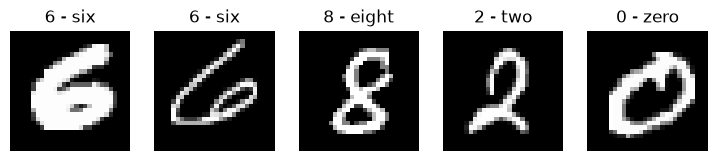

In [3]:
torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))

for i in range(1, 6):
  random_idx = torch.randint(0, len(df_train), size=[1]).item()
  rand_img, label = df_train[random_idx]
  fig.add_subplot(1, 5, i)
  plt.imshow(rand_img.squeeze(), cmap="gray")
  plt.title(df_train.classes[label])
  plt.axis(False)

## 5. Перетворіть навчальні та тестові набори даних MNIST у data loaders за допомогою `torch.utils.data.DataLoader`, встановіть `batch_size=32`.
- Покажіть, яку форму даних вертають дата лоадери.

In [4]:
train_dataload = DataLoader(
    df_train,
    batch_size=32,
    shuffle=True
)

test_dataload = DataLoader(
    df_test,
    batch_size=32,
    shuffle=True
)

images, labels = next(iter(train_dataload))

print(f"Форма images: {images.shape}")  # [batch_size, channels, height, width]
print(f"Форма labels: {labels.shape}")  # [batch_size]
print(f"Тип images: {images.dtype}")
print(f"Тип labels: {labels.dtype}")

Форма images: torch.Size([32, 1, 28, 28])
Форма labels: torch.Size([32])
Тип images: torch.float32
Тип labels: torch.int64


Розмір зображення: torch.Size([1, 28, 28])
Мітка: 4, розмір мітки: torch.Size([])


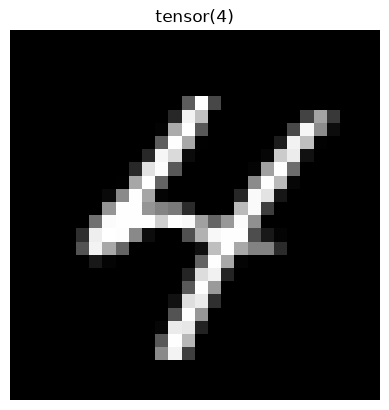

In [5]:
plt.imshow(images[10].squeeze(), cmap="gray")
plt.title(labels[10])
plt.axis("Off");
print(f"Розмір зображення: {images[10].shape}")
print(f"Мітка: {labels[10]}, розмір мітки: {labels[10].shape}")

## 6. Відтворіть `ModelV2`, яку ми розглядали на лекції
Це до слова та сама модель з [сайту CNN Explainer](https://poloclub.github.io/cnn-explainer/), також відома як TinyVGG і вона здатна навчатися на наборі даних MNIST.

Напишіть клас моделі.

In [6]:
class ModelV2(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.block_2 = nn.Sequential(
        nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
        nn.ReLU(),
        nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*7*7,
                      out_features=output_shape)
    )

  def forward(self, x: torch.Tensor):
    x = self.block_1(x)
    # print(x.shape)
    x = self.block_2(x)
    # print(x.shape)
    x = self.classifier(x)
    # print(x.shape)
    return x

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"

torch.manual_seed(42)
model = ModelV2(
    input_shape=1,
    hidden_units=10,
    output_shape=10).to(device)
model

ModelV2(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

## 7. Навчіть модель, яку ви побудували в попередній вправі, протягом 5 епох на CPU та GPU і подивіться, скільки часу це займе в кожному з варіантів.

In [8]:
def train_step(
      model: nn.Module,
      optimizer: torch.optim.Optimizer,
      data_loader: torch.utils.data.DataLoader,
      loss_fn: torch.nn.Module,
      accuracy_fn,
      device: torch.device = device
):
  train_loss, train_acc = 0, 0
  model.to(device)

  for batch, (X,y) in enumerate(data_loader):
    X, y = X.to(device), y.to(device)

    y_pred = model(X)
    loss = loss_fn(y_pred, y)
    train_loss += loss
    train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


  train_loss /= len(data_loader)
  train_acc /= len(data_loader)
  print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")

def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)

            test_pred = model(X)
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y,
                y_pred=test_pred.argmax(dim=1)
            )
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")

In [9]:
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.1)

In [10]:
from tqdm.auto import tqdm

In [11]:
from timeit import default_timer as timer
def print_train_time(start: float, end: float, device: torch.device = None):
    total_time = end - start
    print(f"Час навчання на {device}: {total_time:.3f} секунд")
    return total_time

In [12]:
torch.manual_seed(42)

from timeit import default_timer as timer
train_time_start_on_gpu = timer()

epochs = 5
for epoch in tqdm(range(epochs)):
    print(f"Епоха: {epoch}\n---------")
    train_step(data_loader=train_dataload,
        model=model,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn
    )
    test_step(data_loader=test_dataload,
        model=model,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn
    )

train_time_end_on_gpu = timer()
total_train_time_model_1 = print_train_time(start=train_time_start_on_gpu,
                                            end=train_time_end_on_gpu,
                                            device=device)

  0%|          | 0/5 [00:00<?, ?it/s]

Епоха: 0
---------
Train loss: 0.33484 | Train accuracy: 88.80%
Test loss: 0.07205 | Test accuracy: 97.68%

Епоха: 1
---------
Train loss: 0.08166 | Train accuracy: 97.48%
Test loss: 0.05637 | Test accuracy: 98.16%

Епоха: 2
---------
Train loss: 0.06555 | Train accuracy: 97.96%
Test loss: 0.06354 | Test accuracy: 98.01%

Епоха: 3
---------
Train loss: 0.05566 | Train accuracy: 98.31%
Test loss: 0.04568 | Test accuracy: 98.30%

Епоха: 4
---------
Train loss: 0.04923 | Train accuracy: 98.44%
Test loss: 0.04361 | Test accuracy: 98.47%

Час навчання на cuda: 58.643 секунд


In [13]:
device = 'cpu'

torch.manual_seed(42)
model = ModelV2(
    input_shape=1,
    hidden_units=10,
    output_shape=10).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.1)

from timeit import default_timer as timer
train_time_start_on_gpu = timer()

epochs = 5
for epoch in tqdm(range(epochs)):
    print(f"Епоха: {epoch}\n---------")
    train_step(data_loader=train_dataload,
        model=model,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn
    )
    test_step(data_loader=test_dataload,
        model=model,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn
    )

train_time_end_on_gpu = timer()
total_train_time_model_1 = print_train_time(start=train_time_start_on_gpu,
                                            end=train_time_end_on_gpu,
                                            device=device)

  0%|          | 0/5 [00:00<?, ?it/s]

Епоха: 0
---------
Train loss: 0.26634 | Train accuracy: 91.27%
Test loss: 0.07626 | Test accuracy: 97.47%

Епоха: 1
---------
Train loss: 0.06825 | Train accuracy: 97.86%
Test loss: 0.04045 | Test accuracy: 98.50%

Епоха: 2
---------
Train loss: 0.05241 | Train accuracy: 98.37%
Test loss: 0.04519 | Test accuracy: 98.46%

Епоха: 3
---------
Train loss: 0.04434 | Train accuracy: 98.57%
Test loss: 0.03680 | Test accuracy: 98.88%

Епоха: 4
---------
Train loss: 0.03934 | Train accuracy: 98.75%
Test loss: 0.04137 | Test accuracy: 98.53%

Час навчання на cpu: 58.537 секунд


## 8. Зробіть прогнози за допомогою вашої навченої моделі та візуалізуйте принаймні 5 з них, порівнюючи прогноз з цільовою міткою.

In [14]:
from PIL import Image
from torchvision import transforms

img_1 = Image.open("one.png").convert("L")  # у відтінки сірого
img_3 = Image.open("three.png").convert("L")
img_7 = Image.open("seven.png").convert("L")
img_8 = Image.open("eight.png").convert("L")
img_9 = Image.open("nine.png").convert("L")

transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
])
img_list = [img_1, img_3, img_7, img_8, img_9]

img_list_tensors = []
for i in img_list:
  img_tensor = transform(i).unsqueeze(0).to(next(model.parameters()).device)
  img_list_tensors.append(img_tensor)

model.eval()
with torch.inference_mode():
  for i in img_list_tensors:
    pred = model(i)
    print(pred.argmax(dim=1))

tensor([4], device='cuda:0')
tensor([3], device='cuda:0')
tensor([1], device='cuda:0')
tensor([3], device='cuda:0')
tensor([3], device='cuda:0')


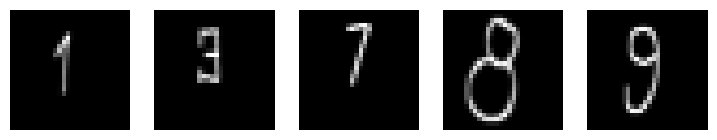

In [15]:
fig = plt.figure(figsize=(9, 9))

for idx, i in enumerate(img_list_tensors):
  plt.subplot(1, 5, idx + 1)
  plt.imshow(i.squeeze().cpu(), cmap="gray")
  plt.axis(False)

я використав зображення намальовані від руки і привів до формату 28х28.
і хоча модель показує високу точність та на моїх кастомних зображеннях 7 плутає з 1, 8 плутає з 3, 1 плутає з 4
враховуючи якість зображень з прикладів вище, де візуалізували 5 прикладів припускаю що мої приклади занадто нечіткі і дрібрі, можливо модель мало бачила подібних варіантів і не навчилась розпізнавати подібне.

## 9. Побудуйте матрицю плутанини, порівнюючи передбачення вашої моделі з істинними мітками.

In [16]:
# Імпортуйте оновлену версію mlxtend
import mlxtend
print(mlxtend.__version__)
assert int(mlxtend.__version__.split(".")[1]) >= 19 # повинна бути версія 0.19.0 або вище

0.25.0


In [26]:
device = 'cuda'
# Імпортуємо tqdm для індикатора прогресу
from tqdm.auto import tqdm

# 1. Зробіть прогнози з навченою моделлю
y_preds = []
y_true = []
X_train = []
model.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataload, desc="Зроблення прогнозів"):
    # Відправте дані та цілі на цільовий пристрій
    X, y = X.to(device), y.to(device)
    # Виконайте прямий прохід
    y_logit = model(X)
    # Перетворіть прогнози з логітів -> ймовірності прогнозів -> мітки прогнозів
    y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1) # зауваження: виконуйте softmax на вимірі "логітів", а не "пакету" (в даному випадку у нас розмір пакету 32, тому можна виконати на dim=1)
    # Помістіть прогнози на CPU для оцінки
    y_preds.append(y_pred.cpu())
    y_true.append(y.cpu())
    X_train.append(X.cpu())
# Об'єднайте список прогнозів в тензор
y_pred_tensor = torch.cat(y_preds)
y_true = torch.cat(y_true)
X_train = torch.cat(X_train)

Зроблення прогнозів:   0%|          | 0/313 [00:00<?, ?it/s]

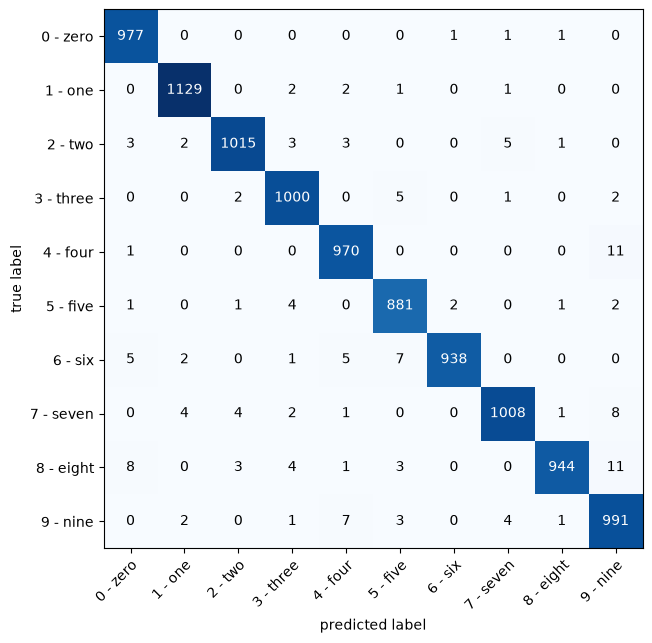

In [21]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

class_names = df_train.classes
# 2. Налаштування екземпляра матриці плутанини та порівняння прогнозів з цілями
confmat = ConfusionMatrix(num_classes=len(class_names), task='multiclass')
confmat_tensor = confmat(preds=y_pred_tensor,
                         target=y_true)

# 3. Побудова матриці плутанини
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(), # matplotlib любить працювати з NumPy
    class_names=class_names, # перетворення міток рядків і стовпців на назви класів
    figsize=(10, 7)
);

Дійсно, виглядає чудово, помилок зовсім мало, можна хіба що виділити що 4 інколи плутається з 9 (дійсно може бути схожість), 8 з 9

## 10. Виведіть принаймні 9 прикладів, де модель помиляється, разом з тим, якою мала бути мітка зображення.
* Після візуалізації цих прогнозів, як ви думаєте, це більше помилка моделювання чи помилка даних?
* Тобто, чи може модель працювати краще, чи мітки даних занадто близькі одна до одної, що навіть людина не може чітко розрізнити що це за цифра?

Усього помилок: 147


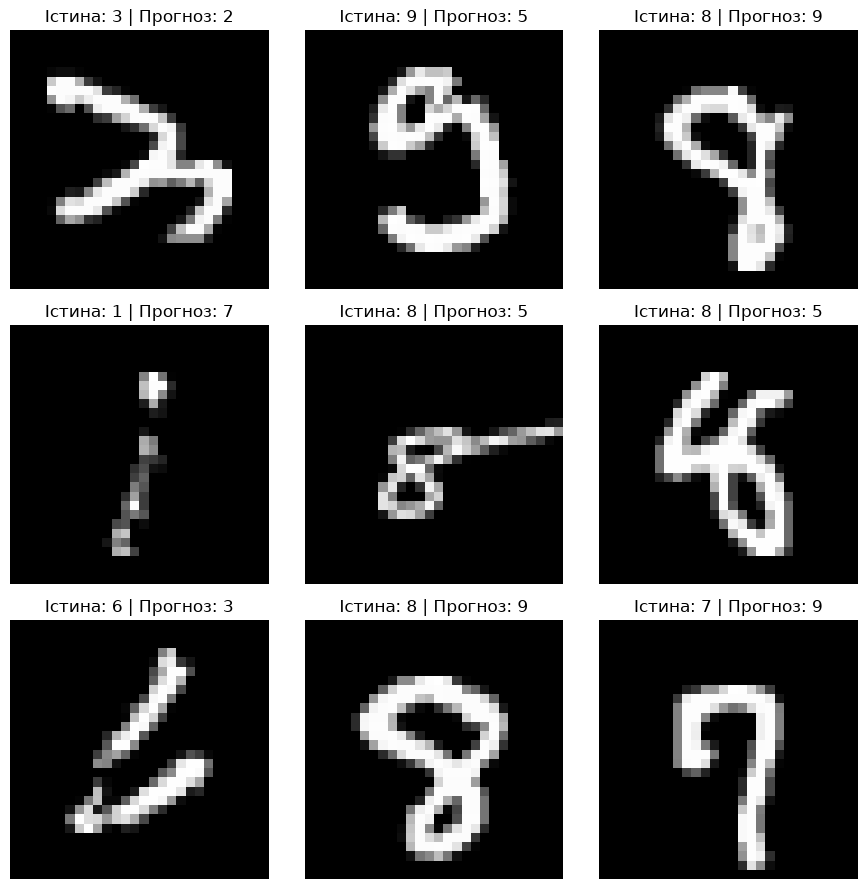

In [28]:
# маска: True там, де прогноз не збігся з істиною
wrong_mask = y_pred_tensor != y_true

# відбираємо лише помилкові
wrong_images = X_train[wrong_mask]
wrong_true   = y_true[wrong_mask]
wrong_pred   = y_pred_tensor[wrong_mask]

print(f"Усього помилок: {len(wrong_images)}")

# показуємо кілька
n = 9
plt.figure(figsize=(9, 9))
for idx in range(min(n, len(wrong_images))):
    plt.subplot(3, 3, idx + 1)
    plt.imshow(wrong_images[idx].squeeze(), cmap="gray")
    plt.title(f"Істина: {wrong_true[idx]} | Прогноз: {wrong_pred[idx]}")
    plt.axis(False)
plt.tight_layout()


Точно є картинки, які і людина не відразу зрозуміє( наприклад перша четверта і сьома, взагалі незрозуміло що там)
Решта - так, вони дійсно мають певні нечіткості і особливості почерку, але можна спробувати покращити модель і спробувати додаткові експерименти

## 11. Створіть випадковий тензор форми `[1, 3, 64, 64]` і пропустіть його через шар `nn.Conv2d()` з різними налаштуваннями гіперпараметрів (ви можете вибрати будь-які налаштування), що ви помічаєте, якщо параметр `kernel_size` збільшується або зменшується?

In [41]:
rand_tens = torch.randn(size=(1,3,64,64))

conv2layer = nn.Conv2d(
    in_channels = 3,
    out_channels = 10,
    kernel_size = 3,
    stride = 1,
    padding = 1
)

conv2l_tensor = conv2layer(rand_tens)
conv2l_tensor.shape

torch.Size([1, 10, 64, 64])

In [42]:
rand_tens = torch.randn(size=(1,3,64,64))

conv2layer = nn.Conv2d(
    in_channels = 3,
    out_channels = 10,
    kernel_size = 6,
    stride = 1,
    padding = 1
)

conv2l_tensor = conv2layer(rand_tens)
conv2l_tensor.shape

torch.Size([1, 10, 61, 61])

коли ми змінюємо kernel_size то міняється формат feature maps - вона стає меншою. і це логічно - ми беремо більшого розміру квадрат щоб обраховувати прояв якоїсь ознаки, був квадрат пікселів 3х3, став 5х5, зображення "згорнулось" в більшій мірі

In [44]:
rand_tens = torch.randn(size=(1,3,64,64))

conv2layer = nn.Conv2d(
    in_channels = 3,
    out_channels = 10,
    kernel_size = 6,
    stride = 3,
    padding = 1
)

conv2l_tensor = conv2layer(rand_tens)
conv2l_tensor.shape

torch.Size([1, 10, 21, 21])

те саме стосується stride - чим більший крок тим feature maps буде менш деталізованим так як ми kernel зміщуємо не на 1 піксель а на 3, згортка буде ще більша, але здаєтсья втратимо деталізацію.

padding не виводив, але суть та сама - чим більші відступи від оригінального зображення тим згортка буде більша, але робити padding великим нема сенсу так як зображення наповниться нулями